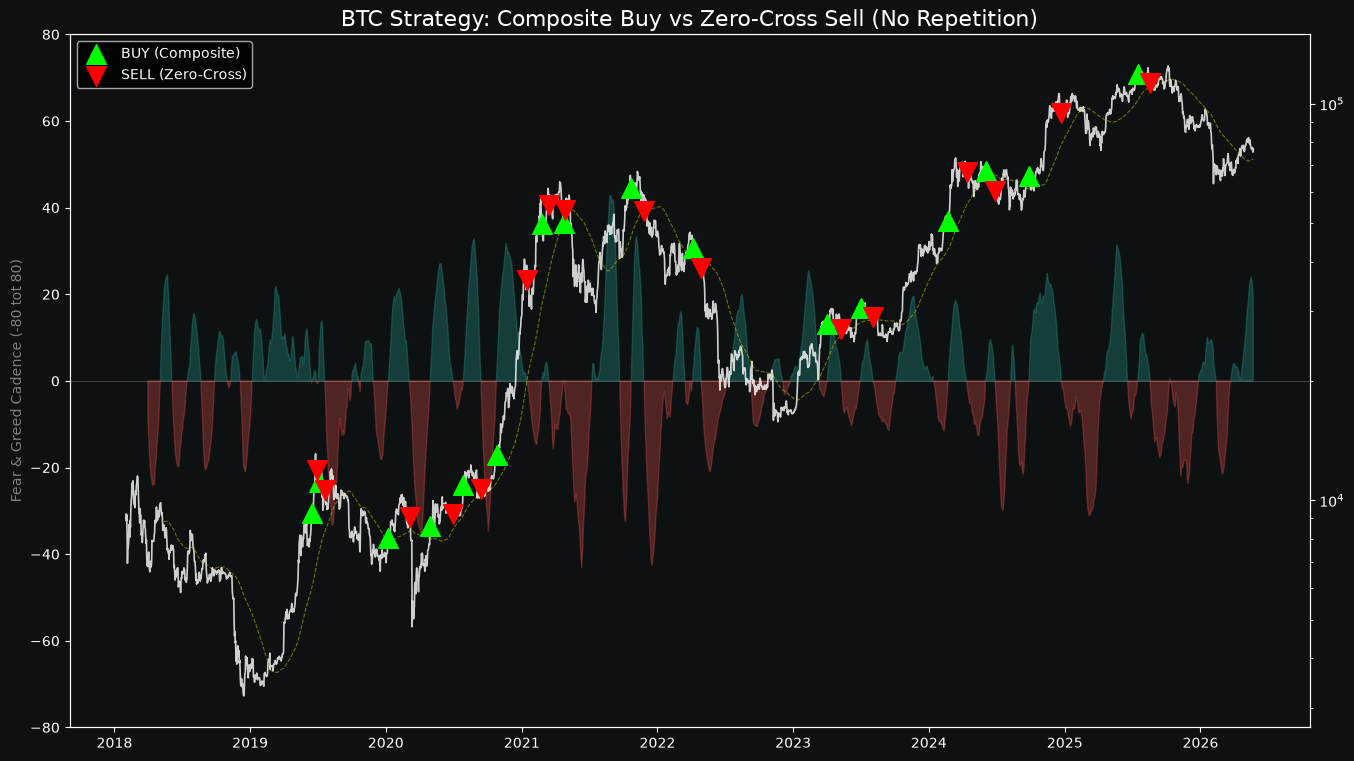

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ta.trend import SMAIndicator

# --- 1. DATA INLADEN & VOORBEREIDEN ---
df_btc = pd.read_csv("btc_1d.csv", parse_dates=["timestamp"])
df_btc.set_index("timestamp", inplace=True)
df_fng = pd.read_csv("fear_and_greed_index_2020_2026.csv", parse_dates=["date"])
df_fng.set_index("date", inplace=True)

df_btc.index = df_btc.index.tz_localize(None)
df_fng.index = df_fng.index.tz_localize(None)
df = df_btc.join(df_fng, how='inner')
df['fng_value'] = pd.to_numeric(df['fng_value'])
df.sort_index(inplace=True)

# --- 2. INDICATOREN BEREKENEN ---
df['sma200'] = SMAIndicator(close=df['close'], window=100).sma_indicator()
df['cadence'] = df['fng_value'] - df['fng_value'].shift(30)
df['cadence_smooth'] = df['cadence'].rolling(window=30).mean()

# --- 3. STATE MACHINE VOOR SIGNALEN (Geen dubbele signalen) ---
# We maken lege kolommen voor de definitieve signalen
df['final_buy'] = False
df['final_sell'] = False

in_position = False # Track of we in een trade zitten

for i in range(1, len(df)):
    current_cadence = df['cadence_smooth'].iloc[i]
    prev_cadence = df['cadence_smooth'].iloc[i-1]
    current_price = df['close'].iloc[i]
    current_sma = df['sma200'].iloc[i]
    current_fng = df['fng_value'].iloc[i]

    # KOOP LOGICA (Alleen als we NIET in positie zijn)
    if not in_position:
        if (current_cadence > 0 and prev_cadence <= 0 and
            current_price > current_sma and
            current_fng > 20):
            df.iloc[i, df.columns.get_loc('final_buy')] = True
            in_position = True

    # VERKOOP LOGICA (Alleen als we WEL in positie zijn)
    elif in_position:
        if current_cadence < 0 and prev_cadence >= 0:
            df.iloc[i, df.columns.get_loc('final_sell')] = True
            in_position = False

# --- 4. PLOTTEN ---
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(16, 9), facecolor='#0e1111')
ax1.set_facecolor('#0e1111')

# Cadence as instellen op -80 tot 80
ax1.set_ylim(-80, 80)
ax1.fill_between(df.index, 0, df['cadence_smooth'], where=(df['cadence_smooth'] >= 0), color='#26a69a', alpha=0.3)
ax1.fill_between(df.index, 0, df['cadence_smooth'], where=(df['cadence_smooth'] < 0), color='#ef5350', alpha=0.3)
ax1.axhline(0, color='white', linewidth=0.5, alpha=0.3)
ax1.set_ylabel('Fear & Greed Cadence (-80 tot 80)', color='gray')

# Prijs as
ax2 = ax1.twinx()
ax2.plot(df.index, df['close'], color='white', linewidth=1.2, alpha=0.8)
ax2.plot(df.index, df['sma200'], color='yellow', linewidth=0.8, alpha=0.4, linestyle='--')
ax2.set_yscale('log')

# Teken de gefilterde signalen
ax2.scatter(df.index[df['final_buy']], df.loc[df['final_buy'], 'close'],
            marker='^', color='#00ff00', s=200, label='BUY (Composite)', zorder=5)
ax2.scatter(df.index[df['final_sell']], df.loc[df['final_sell'], 'close'],
            marker='v', color='#ff0000', s=200, label='SELL (Zero-Cross)', zorder=5)

plt.title("BTC Strategy: Composite Buy vs Zero-Cross Sell (No Repetition)", color='white', fontsize=16)
ax2.legend(loc='upper left')
plt.show()

In [14]:
def run_fg_backtest(df, start_capital=1000.0, fee=0.001):
    """
    Backtest voor de Fear & Greed Cadence strategie.
    - Koopt 'All-in' op de dag van een final_buy.
    - Verkoopt alles op de dag van een final_sell.
    - Houdt rekening met fees (0.1% standaard).
    """
    capital = start_capital
    position_size = 0  # Hoeveelheid BTC in bezit
    equity = []
    trade_returns = []

    in_position = False
    entry_price = 0

    for i in range(len(df)):
        current_price = df['close'].iloc[i]

        # --- ENTRY LOGICA ---
        if df['final_buy'].iloc[i] and not in_position:
            # Koop BTC met al het geld minus fees
            capital_after_fee = capital * (1 - fee)
            position_size = capital_after_fee / current_price
            entry_price = current_price
            capital = 0
            in_position = True

        # --- EXIT LOGICA ---
        elif df['final_sell'].iloc[i] and in_position:
            # Verkoop alle BTC minus fees
            capital = (position_size * current_price) * (1 - fee)

            # Bereken trade return voor stats
            ret = (current_price - entry_price) / entry_price
            trade_returns.append(ret)

            position_size = 0
            in_position = False

        # --- EQUITY TRACKING ---
        if in_position:
            equity.append(position_size * current_price)
        else:
            equity.append(capital)

    # Voeg equity curve toe aan dataframe
    df['equity'] = equity

    # --- PERFORMANCE STATS BEREKENEN ---
    final_val = df['equity'].iloc[-1]
    net_pnl = final_val - start_capital
    total_return_pct = (net_pnl / start_capital) * 100

    # Buy & Hold berekenen
    bh_return_pct = ((df['close'].iloc[-1] - df['close'].iloc[0]) / df['close'].iloc[0]) * 100

    # Max Drawdown
    rolling_max = df['equity'].cummax()
    drawdown = (df['equity'] - rolling_max) / rolling_max
    max_dd = drawdown.min() * 100

    # Winrate
    wins = [r for r in trade_returns if r > 0]
    win_rate = (len(wins) / len(trade_returns) * 100) if len(trade_returns) > 0 else 0

    # Sharpe Ratio (op basis van dagelijkse returns)
    daily_returns = df['equity'].pct_change().dropna()
    sharpe = (daily_returns.mean() / daily_returns.std() * np.sqrt(365)) if daily_returns.std() != 0 else 0

    # Print Resultaten
    print(f"=== F&G STRATEGY BACKTEST ===")
    print(f"Start Kapitaal : ${start_capital:.2f}")
    print(f"Eind Kapitaal  : ${final_val:.2f}")
    print(f"Netto PnL      : ${net_pnl:.2f} ({total_return_pct:.2f}%)")
    print(f"Buy & Hold     : {bh_return_pct:.2f}%")
    print(f"Max Drawdown   : {max_dd:.2f}%")
    print(f"Sharpe Ratio   : {sharpe:.2f}")
    print(f"Aantal Trades  : {len(trade_returns)}")
    print(f"Win Rate       : {win_rate:.2f}%")
    print(f"=============================")

    return df

# Run de backtest
df = run_fg_backtest(df)

=== F&G STRATEGY BACKTEST ===
Start Kapitaal : $1000.00
Eind Kapitaal  : $5377.04
Netto PnL      : $4377.04 (437.70%)
Buy & Hold     : 732.56%
Max Drawdown   : -35.00%
Sharpe Ratio   : 0.86
Aantal Trades  : 16
Win Rate       : 50.00%


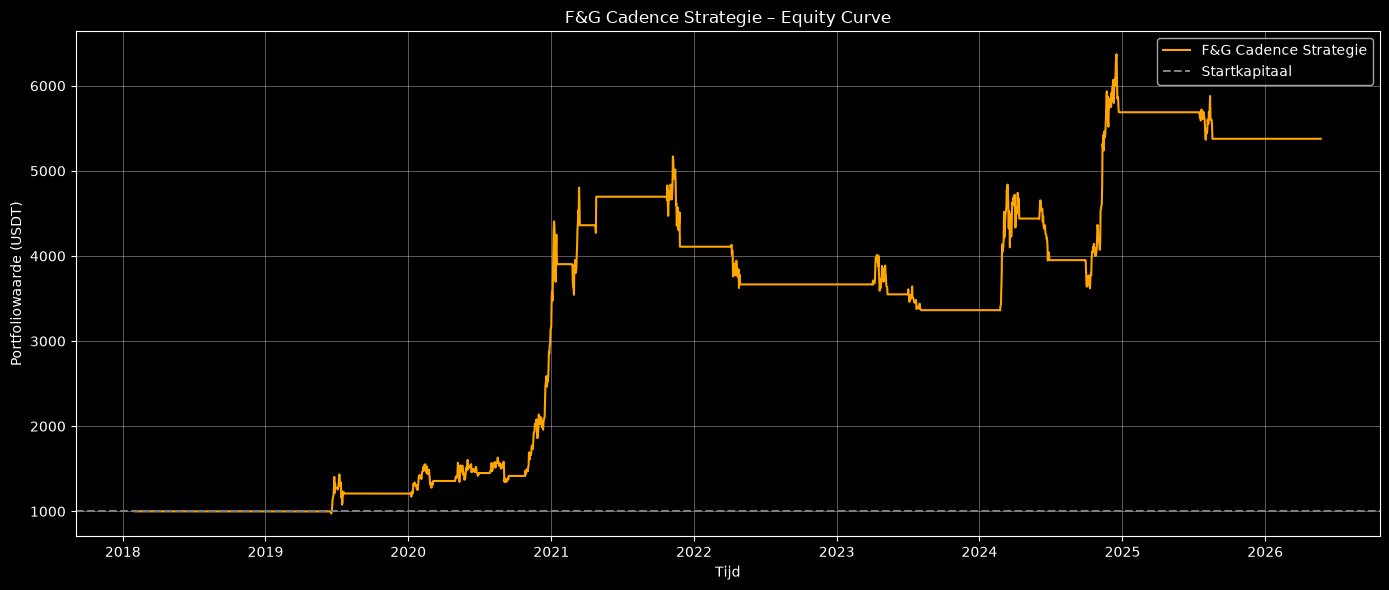

In [15]:
# 2. De losse plot code
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["equity"], label="F&G Cadence Strategie", color="orange")
plt.axhline(df["equity"].iloc[0], color="gray", linestyle="--", label="Startkapitaal")

plt.title("F&G Cadence Strategie – Equity Curve")
plt.xlabel("Tijd")
plt.ylabel("Portfoliowaarde (USDT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

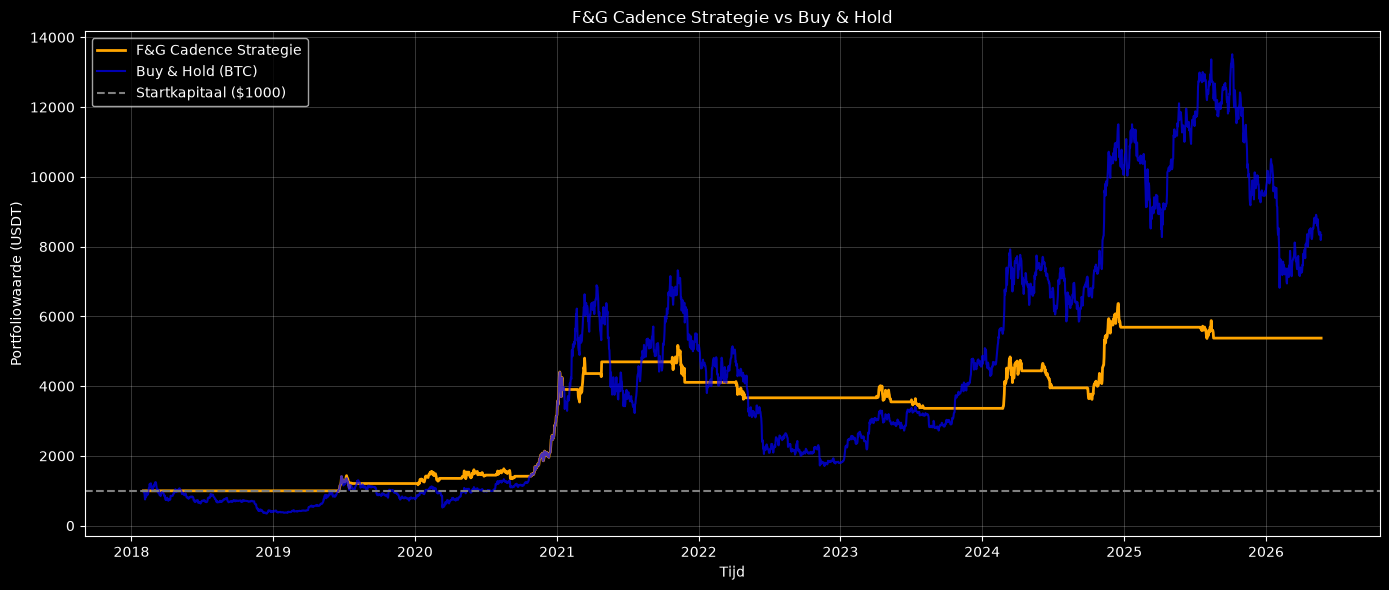

In [16]:
# 1. Bereken de Buy & Hold waarde (vanaf $1000)
start_price = df["close"].iloc[0]
df["buy_hold_value"] = 1000 * (df["close"] / start_price)

# 2. De Plot (Vergelijking Strategie vs BTC Hold)
plt.figure(figsize=(14, 6))

# Jouw strategie lijn
plt.plot(df.index, df["equity"], label="F&G Cadence Strategie", color="orange", linewidth=2)

# De Buy & Hold lijn (Blauw zoals in je voorbeeld)
plt.plot(df.index, df["buy_hold_value"], label="Buy & Hold (BTC)", color="blue", alpha=0.7)

# De startkapitaal lijn
plt.axhline(1000, color="gray", linestyle="--", label="Startkapitaal ($1000)")

plt.title("F&G Cadence Strategie vs Buy & Hold")
plt.xlabel("Tijd")
plt.ylabel("Portfoliowaarde (USDT)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()